# Does MPS simulation actually help QProfiler? A head-to-head on a real task

**Written for:** QBioCode contributors deciding whether to switch the projection backend
for `qpl` / `pqk` runs.

**Task:** PBMC single-cell RNA-seq, **CD4 T cells vs CD8 T cells** — 500 cells, 50 genes,
balanced (250/250). This is `tutorial/QProfiler/data/sc_binary/pbmc-cd4_vs_cd8.csv`,
run through QProfiler exactly as any other QProfiler job.

**Backends compared**, all through `args['projection_backend']`:

| name | what it is |
|---|---|
| `None` (legacy) | `StatevectorEstimator`, what QProfiler used before — re-simulates once per observable |
| `statevector` | dense `2**n` statevector, one simulation per row |
| `aer_mps` | `AerSimulator(method="matrix_product_state")` |
| `quimb_mps` | `quimb.tensor.CircuitMPS` |

## The two questions, and why they are different

1. **Is it the same answer?** All four compute the same Pauli expectation values, so
   accuracy must be *identical*. §3 checks that rather than assuming it — if the metrics
   move, something is wrong, and the speed comparison is meaningless.
2. **Does it let us do something we could not?** This is the real question. Speed only
   matters if it buys a model we could not otherwise fit. QProfiler's usual answer to a
   wide dataset is to PCA it down (`n_components: 3` in the shipped config). §4 asks
   instead: **how many real genes can each backend afford, and does using more of them
   classify better?**

## 0. Setup

In [1]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")   # keep first: several OpenMP runtimes

import json, shutil, time, warnings, platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import yaml

warnings.filterwarnings("ignore")

import qbiocode, quimb, qiskit, qiskit_aer
# Name only: the full path would publish a developer's home directory.
print("qbiocode", Path(qbiocode.__file__).resolve().parent.parent.name)
print("quimb", quimb.__version__, "| qiskit", qiskit.__version__,
      "| aer", qiskit_aer.__version__)
print("cpus", os.cpu_count(), "|", platform.platform())

NOTEBOOK_DIR = Path.cwd()
SOURCE_CSV = NOTEBOOK_DIR / "data" / "sc_binary" / "pbmc-cd4_vs_cd8.csv"
WORK = Path("/tmp/qprofiler_mps_headtohead"); WORK.mkdir(exist_ok=True)

raw = pd.read_csv(SOURCE_CSV)
LABEL = raw.columns[-1]
print(f"\n{SOURCE_CSV.name}: {raw.shape[0]} cells x {raw.shape[1]-1} genes")
print("classes:", raw[LABEL].value_counts().to_dict())

qbiocode QBioCode
quimb 1.15.1.dev57+g800d766aa | qiskit 2.2.0 | aer 0.17.0
cpus 12 | macOS-26.6.2-arm64-arm-64bit

pbmc-cd4_vs_cd8.csv: 500 cells x 50 genes
classes: {'CD4_T': 250, 'CD8_T': 250}


## 1. Driving QProfiler

One helper: write a gene subset to its own folder, point a QProfiler config at it, run
`profiler.main`, and read the row back out of `ModelResults.csv`.

Two details that make the comparison honest:

- **Wall clock is measured around `profiler.main` here**, not taken from the CSV's `time`
  column. That column is per classical head and does not include the projection, which is
  the part the backend changes.
- **Each backend gets its own `qpl_projection_dir`.** `compute_qpl` caches projections to
  `.npy`; without separate directories the second and third backends would load the
  first one's file and appear instantaneous. (`projection_backend` is also part of the
  cache fingerprint now, so this is belt-and-braces.)

In [2]:
from qbiocode.apps.qprofiler import qprofiler as profiler

BASE_CONFIG = yaml.safe_load(open(NOTEBOOK_DIR / "configs" / "config.yaml"))


def make_dataset(n_genes):
    """Write the first `n_genes` genes plus the label to their own folder."""
    d = WORK / f"data_{n_genes}g"; d.mkdir(exist_ok=True)
    csv = d / f"pbmc_cd4_vs_cd8_{n_genes}g.csv"
    if not csv.exists():
        pd.concat([raw.iloc[:, :n_genes], raw[LABEL]], axis=1).to_csv(csv, index=False)
    return d, csv.name


def run_qprofiler(n_genes, projection_backend, reps=1, entanglement="linear",
                  classical_models=("lr", "rf"), n_jobs_proj=1):
    """Run one QProfiler job. Returns the ModelResults rows plus measured wall clock."""
    folder, fname = make_dataset(n_genes)
    tag = f"{n_genes}g_{projection_backend or 'legacy'}_{entanglement}_r{reps}"
    rundir = WORK / "runs" / tag
    if rundir.exists():
        shutil.rmtree(rundir)
    rundir.mkdir(parents=True)

    cfg = dict(BASE_CONFIG)
    cfg.update(
        folder_path=str(folder), file_dataset="ALL",
        model=["qpl"], embeddings=["none"], embedding_min_features=0,
        iter=1, grid_search=False, n_jobs=1, backend="simulator",
        # None means "use the legacy StatevectorEstimator path".
        projection_backend=projection_backend,
        projection_n_jobs=n_jobs_proj,
        qpl_projection_dir=str(rundir / "proj"),
    )
    cfg["qpl_args"] = {"encoding": "ZZ", "entanglement": entanglement, "reps": reps,
                       "primitive": "estimator",
                       "classical_models": list(classical_models)}

    cwd = Path.cwd()
    try:
        os.chdir(rundir)                      # QProfiler writes CSVs into cwd
        t = time.perf_counter()
        profiler.main(cfg)
        wall = time.perf_counter() - t
        mr = pd.read_csv(rundir / "ModelResults.csv")
    finally:
        os.chdir(cwd)

    keep = ["Dataset", "model", "accuracy", "f1_score", "auc"]
    out = mr[keep].copy()
    out["n_genes"] = n_genes
    out["backend"] = projection_backend or "legacy"
    out["reps"] = reps
    out["entanglement"] = entanglement
    out["wall_clock_s"] = wall
    # The projected features themselves, so agreement can be checked directly.
    train_npy = sorted((rundir / "proj").glob("*_train.npy"))
    out.attrs["projection_file"] = str(train_npy[0]) if train_npy else None
    return out


RESULTS_CACHE = WORK / "results.json"
_results = json.loads(RESULTS_CACHE.read_text()) if RESULTS_CACHE.exists() else {}


def cached_run(n_genes, backend, **kw):
    key = f"{n_genes}|{backend}|{kw.get('entanglement','linear')}|{kw.get('reps',1)}"
    if key not in _results:
        df = run_qprofiler(n_genes, backend, **kw)
        _results[key] = {"rows": df.drop(columns=["Dataset"]).to_dict("records"),
                         "projection_file": df.attrs.get("projection_file")}
        RESULTS_CACHE.write_text(json.dumps(_results, indent=1))
    r = _results[key]
    df = pd.DataFrame(r["rows"]); df.attrs["projection_file"] = r["projection_file"]
    return df


print("helper ready; work dir:", WORK)

helper ready; work dir: /tmp/qprofiler_mps_headtohead


### Chart style

In [3]:
SERIES_COLOR = {"legacy": "#e34948", "statevector": "#eb6834",
                "aer_mps": "#1baf7a", "quimb_mps": "#2a78d6"}
MARKER = {"legacy": "x", "statevector": "s", "aer_mps": "^", "quimb_mps": "o"}
ORDER = ["legacy", "statevector", "aer_mps", "quimb_mps"]
SURFACE, INK, INK_2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e5e4e0"

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "savefig.dpi": 200, "figure.dpi": 130,
    "text.color": INK, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "xtick.color": INK_2, "ytick.color": INK_2,
    "axes.edgecolor": GRID, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": GRID, "grid.linewidth": 0.8, "axes.grid": True, "axes.axisbelow": True,
    "legend.frameon": False, "font.size": 10.5,
    "axes.titlesize": 12.5, "axes.titleweight": "600",
})

## 2. Experiment A — the head-to-head

12 genes, so all four backends are affordable (the legacy path is the constraint: it
re-simulates once per observable, so 36 observables x 500 cells).

Same feature map throughout: `ZZ`, `entanglement="linear"`, `reps=1`. Two classical heads
(`lr`, `rf`) are fitted on the projection, exactly as `compute_qpl` normally does.

In [4]:
A_GENES = 12
rows_a = []
for backend in [None, "statevector", "aer_mps", "quimb_mps"]:
    df = cached_run(A_GENES, backend)
    rows_a.append(df)
    print(f"  {str(backend or 'legacy'):<12} wall {df.wall_clock_s.iloc[0]:7.1f}s   "
          + "  ".join(f"{r.model}: acc {r.accuracy:.4f} auc {r.auc:.4f}"
                      for r in df.itertuples()), flush=True)
df_a = pd.concat(rows_a, ignore_index=True)

  legacy       wall    44.5s   qpl_lr: acc 0.8867 auc 0.9239  qpl_rf: acc 0.8933 auc 0.9163


  statevector  wall    11.8s   qpl_lr: acc 0.8867 auc 0.9239  qpl_rf: acc 0.8933 auc 0.9163


  aer_mps      wall    12.0s   qpl_lr: acc 0.8867 auc 0.9239  qpl_rf: acc 0.8933 auc 0.9163


  quimb_mps    wall    14.9s   qpl_lr: acc 0.8867 auc 0.9239  qpl_rf: acc 0.8933 auc 0.9163


In [5]:
# Do the four backends really produce the same features? Compare the saved arrays.
ref_file = df_a[df_a.backend == "legacy"].attrs.get("projection_file")
ref_file = _results[f"{A_GENES}|None|linear|1"]["projection_file"]
ref = np.load(ref_file)
print(f"projection array shape {ref.shape} (cells, 3 Paulis, qubits)\n")
print("max |difference| in the projected features, vs the legacy path:")
for backend in ["statevector", "aer_mps", "quimb_mps"]:
    f = _results[f"{A_GENES}|{backend}|linear|1"]["projection_file"]
    print(f"  {backend:<12} {np.abs(np.load(f) - ref).max():.2e}")

print("\nmetric agreement (should be exact -- identical features, identical seeds):")
piv = df_a.pivot_table(index="model", columns="backend", values=["accuracy", "auc"])
print(piv.round(6).to_string())
spread = df_a.groupby("model")[["accuracy", "auc"]].agg(lambda s: s.max() - s.min())
print("\nspread across backends per head:")
print(spread.to_string())

projection array shape (350, 3, 12) (cells, 3 Paulis, qubits)

max |difference| in the projected features, vs the legacy path:
  statevector  0.00e+00
  aer_mps      2.96e-14
  quimb_mps    3.12e-14

metric agreement (should be exact -- identical features, identical seeds):
         accuracy                                       auc                                
backend   aer_mps    legacy quimb_mps statevector   aer_mps    legacy quimb_mps statevector
model                                                                                      
qpl_lr   0.886667  0.886667  0.886667    0.886667  0.923911  0.923911  0.923911    0.923911
qpl_rf   0.893333  0.893333  0.893333    0.893333  0.916267  0.916267  0.916267    0.916267

spread across backends per head:
        accuracy  auc
model                
qpl_lr       0.0  0.0
qpl_rf       0.0  0.0


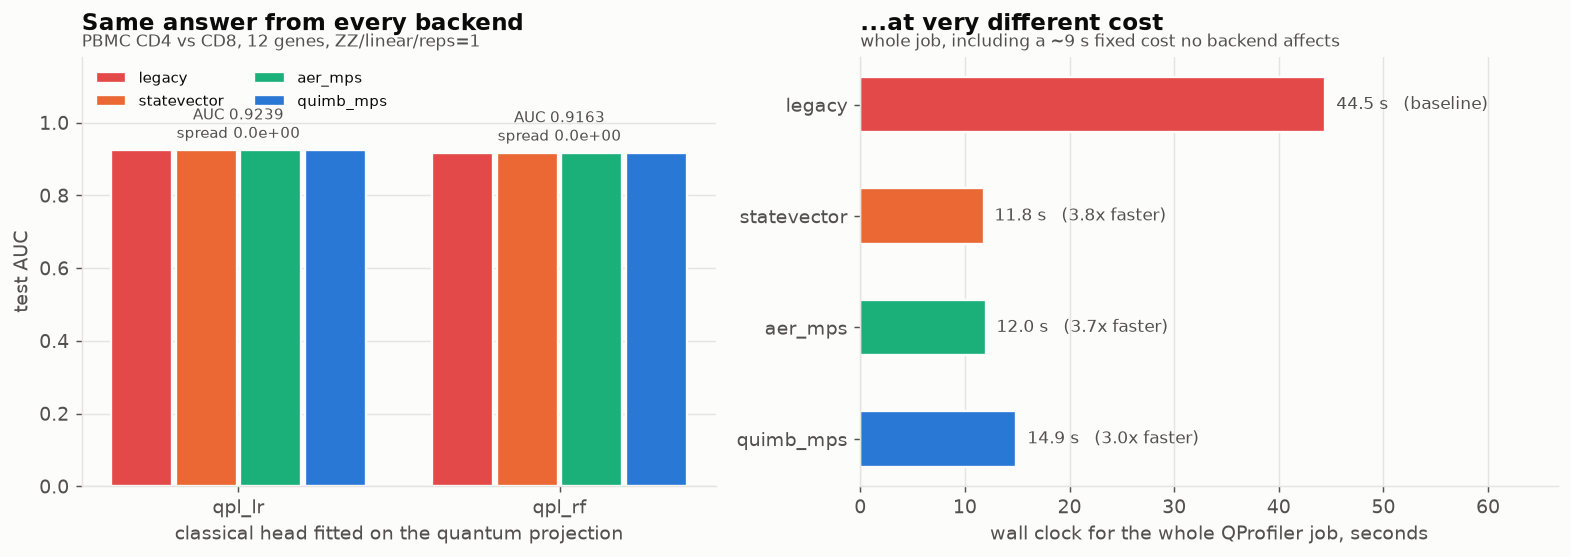

In [6]:
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12.2, 4.4),
                              gridspec_kw={"width_ratios": [1, 1.1]})

# Left: the metrics. Identical by construction, so the point is that the bars line up.
heads = sorted(df_a.model.unique())
xs = np.arange(len(heads), dtype=float); W = 0.19
for i, b in enumerate(ORDER):
    vals = [df_a[(df_a.backend == b) & (df_a.model == h)].auc.iloc[0] for h in heads]
    ax.bar(xs + (i - 1.5) * (W + 0.012), vals, W, label=b, color=SERIES_COLOR[b],
           edgecolor=SURFACE, linewidth=1.3)
for i, h in enumerate(heads):
    v = df_a[df_a.model == h].auc
    ax.annotate(f"AUC {v.iloc[0]:.4f}\nspread {v.max()-v.min():.1e}",
                (xs[i], v.max()), ha="center", va="bottom",
                textcoords="offset points", xytext=(0, 4), fontsize=8.5, color=INK_2)
ax.set_xticks(xs); ax.set_xticklabels(heads)
ax.set_ylim(0, 1.18); ax.set_ylabel("test AUC")
ax.set_xlabel("classical head fitted on the quantum projection")
ax.set_title("Same answer from every backend", loc="left", pad=15)
ax.text(0, 1.025, f"PBMC CD4 vs CD8, {A_GENES} genes, ZZ/linear/reps=1",
        transform=ax.transAxes, fontsize=9.5, color=INK_2)
ax.grid(axis="x", visible=False); ax.legend(loc="upper left", ncol=2, fontsize=8.5)

# Right: wall clock. Zero baseline, linear -- bar length is the quantity.
walls = [df_a[df_a.backend == b].wall_clock_s.iloc[0] for b in ORDER]
ax2.barh(range(len(ORDER))[::-1], walls, 0.5,
         color=[SERIES_COLOR[b] for b in ORDER], edgecolor=SURFACE, linewidth=1.3)
legacy = df_a[df_a.backend == "legacy"].wall_clock_s.iloc[0]
for i, (b, v) in zip(range(len(ORDER))[::-1], zip(ORDER, walls)):
    lab = f"{v:.1f} s" + (f"   ({legacy/v:.1f}x faster)" if b != "legacy" else "   (baseline)")
    ax2.annotate(lab, (v, i), xytext=(6, 0), textcoords="offset points",
                 va="center", fontsize=9.5, color=INK_2)
ax2.set_yticks(range(len(ORDER))[::-1]); ax2.set_yticklabels(ORDER)
ax2.set_xlim(0, max(walls) * 1.5)
ax2.set_xlabel("wall clock for the whole QProfiler job, seconds")
ax2.set_title("...at very different cost", loc="left", pad=15)
# The bars include ~9 s of fixed QProfiler cost (metafeature evaluation, both
# classical fits) that no backend affects, so these ratios UNDERSTATE the projection
# speedup. Section 3's right panel separates the part that scales.
ax2.text(0, 1.025, "whole job, including a ~9 s fixed cost no backend affects",
         transform=ax2.transAxes, fontsize=9.5, color=INK_2)
ax2.grid(axis="y", visible=False)
fig.tight_layout(); plt.show()

## 3. Experiment B — what the speed actually buys

Speed is only interesting if it changes what you can fit. So: hold everything else fixed
and increase the number of **real genes** (one qubit per gene), asking two things at once —
how far each backend gets, and whether more genes classify better.

The legacy path is dropped here; §2 established it is the same answer, and at 20+ genes it
would take hours. The dense statevector is run only where it is affordable: cost per cell
grows exponentially, and there are 500 cells.

In [7]:
WIDTHS_ALL = [8, 12, 16, 20]        # every backend
WIDTHS_MPS = [24, 30, 40, 50]       # MPS only -- 50 = every gene in the dataset

rows_b = []
for n in WIDTHS_ALL:
    for backend in ["statevector", "aer_mps", "quimb_mps"]:
        df = cached_run(n, backend)
        rows_b.append(df)
        print(f"  {n:>3} genes  {backend:<12} wall {df.wall_clock_s.iloc[0]:7.1f}s  "
              f"best AUC {df.auc.max():.4f}", flush=True)
for n in WIDTHS_MPS:
    for backend in ["aer_mps", "quimb_mps"]:
        df = cached_run(n, backend)
        rows_b.append(df)
        print(f"  {n:>3} genes  {backend:<12} wall {df.wall_clock_s.iloc[0]:7.1f}s  "
              f"best AUC {df.auc.max():.4f}", flush=True)
df_b = pd.concat(rows_b, ignore_index=True)

    8 genes  statevector  wall     9.4s  best AUC 0.9305


    8 genes  aer_mps      wall     9.6s  best AUC 0.9305


    8 genes  quimb_mps    wall    12.1s  best AUC 0.9305


   12 genes  statevector  wall    11.8s  best AUC 0.9239


   12 genes  aer_mps      wall    12.0s  best AUC 0.9239


...

   30 genes  quimb_mps    wall    22.1s  best AUC 0.9689


   40 genes  aer_mps      wall    14.4s  best AUC 0.9714


   40 genes  quimb_mps    wall    26.3s  best AUC 0.9714


   50 genes  aer_mps      wall    16.5s  best AUC 0.9735


   50 genes  quimb_mps    wall    30.4s  best AUC 0.9735


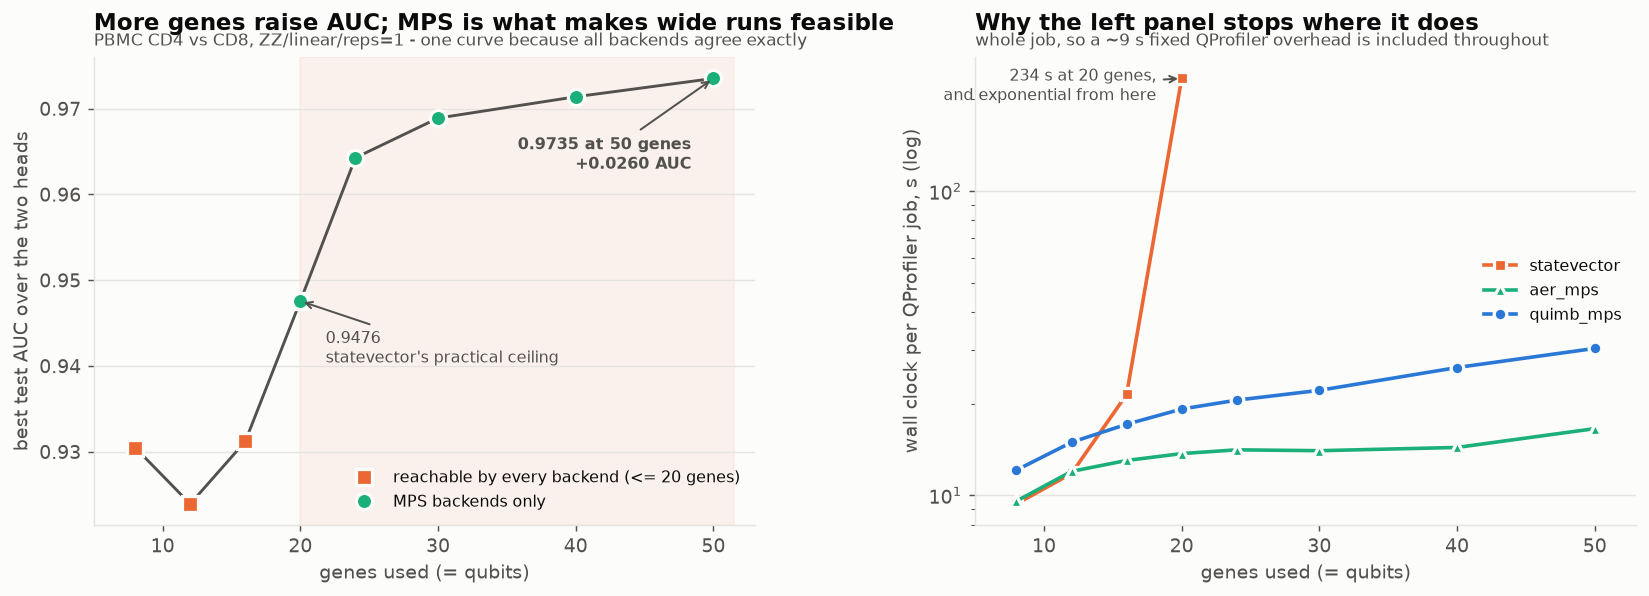

            auc                          wall                      
backend aer_mps quimb_mps statevector aer_mps quimb_mps statevector
n_genes                                                            
8         0.930     0.930       0.930   9.563    12.091       9.359
12        0.924     0.924       0.924  11.973    14.924      11.785
16        0.931     0.931       0.931  13.004    17.106      21.435
20        0.948     0.948       0.948  13.702    19.195     234.276
24        0.964     0.964         NaN  14.096    20.531         NaN
30        0.969     0.969         NaN  14.004    22.112         NaN
40        0.971     0.971         NaN  14.352    26.278         NaN
50        0.974     0.974         NaN  16.548    30.370         NaN

AUC at 20 genes (statevector ceiling): 0.9476
AUC at 50 genes (MPS only):            0.9735
gain from the genes only MPS can afford:    +0.0260

CAUTION: this gain is attributable to the extra GENES, not to the quantum
projection. A matched classical 

In [8]:
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12.8, 4.7))

best = (df_b.groupby(["backend", "n_genes"])
             .agg(auc=("auc", "max"), wall=("wall_clock_s", "first")).reset_index())

# LEFT: AUC depends only on the gene count -- section 2 showed every backend returns
# identical features, so three overlapping lines would hide two of themselves behind the
# last one drawn and falsely suggest statevector has points past 20. One curve; the
# backend only decides how far RIGHT you can go.
auc_by_n = best.groupby("n_genes").auc.agg(["min", "max"]).reset_index()
assert np.allclose(auc_by_n["min"], auc_by_n["max"]), \
    "backends disagree on AUC -- they should be identical; do not plot a single curve"
sv_max = int(best[best.backend == "statevector"].n_genes.max())

reach_all = auc_by_n[auc_by_n.n_genes <= sv_max]
mps_only = auc_by_n[auc_by_n.n_genes >= sv_max]

ax.axvspan(sv_max, 51.5, color=SERIES_COLOR["statevector"], alpha=0.07, zorder=0)
ax.plot(auc_by_n.n_genes, auc_by_n["max"], color=INK_2, linewidth=1.6, zorder=2)
ax.plot(reach_all.n_genes, reach_all["max"], marker="s", markersize=9, linewidth=0,
        color=SERIES_COLOR["statevector"], markeredgecolor=SURFACE, markeredgewidth=1.8,
        label=f"reachable by every backend (<= {sv_max} genes)", zorder=3)
ax.plot(mps_only.n_genes, mps_only["max"], marker="o", markersize=9, linewidth=0,
        color=SERIES_COLOR["aer_mps"], markeredgecolor=SURFACE, markeredgewidth=1.8,
        label="MPS backends only", zorder=3)

auc_at_cap = float(auc_by_n.loc[auc_by_n.n_genes == sv_max, "max"].iloc[0])
auc_at_max = float(auc_by_n["max"].iloc[-1])
n_max = int(auc_by_n.n_genes.iloc[-1])
ax.annotate(f"{auc_at_cap:.4f}\nstatevector's practical ceiling",
            xy=(sv_max, auc_at_cap), xytext=(14, -34), textcoords="offset points",
            ha="left", fontsize=9, color=INK_2,
            arrowprops=dict(arrowstyle="->", color=INK_2, linewidth=1.1))
ax.annotate(f"{auc_at_max:.4f} at {n_max} genes\n+{auc_at_max-auc_at_cap:.4f} AUC",
            xy=(n_max, auc_at_max), xytext=(-12, -50), textcoords="offset points",
            ha="right", fontsize=9, color=INK_2, fontweight="600",
            arrowprops=dict(arrowstyle="->", color=INK_2, linewidth=1.1))

ax.set_xlabel("genes used (= qubits)"); ax.set_ylabel("best test AUC over the two heads")
ax.set_xlim(5, 53)
ax.set_title("More genes raise AUC; MPS is what makes wide runs feasible",
             loc="left", pad=15)
ax.text(0, 1.025, "PBMC CD4 vs CD8, ZZ/linear/reps=1 - one curve because all backends agree exactly",
        transform=ax.transAxes, fontsize=9.5, color=INK_2)
ax.grid(axis="x", visible=False); ax.legend(loc="lower right", fontsize=9)

# RIGHT: the feasibility frontier that makes the left panel possible.
for b in ["statevector", "aer_mps", "quimb_mps"]:
    d = best[best.backend == b].sort_values("n_genes")
    ax2.plot(d.n_genes, d.wall, label=b, color=SERIES_COLOR[b], marker=MARKER[b],
             markersize=7, linewidth=2, markeredgecolor=SURFACE, markeredgewidth=1.8)
sv_last = best[(best.backend == "statevector") & (best.n_genes == sv_max)].wall.iloc[0]
ax2.annotate(f"{sv_last:.0f} s at {sv_max} genes,\nand exponential from here",
             xy=(sv_max, sv_last), xytext=(-14, -12), textcoords="offset points",
             ha="right", fontsize=9, color=INK_2,
             arrowprops=dict(arrowstyle="->", color=INK_2, linewidth=1.1))
ax2.set_yscale("log"); ax2.set_xlabel("genes used (= qubits)")
ax2.set_ylabel("wall clock per QProfiler job, s (log)")
ax2.set_title("Why the left panel stops where it does", loc="left", pad=15)
ax2.text(0, 1.025, "whole job, so a ~9 s fixed QProfiler overhead is included throughout",
         transform=ax2.transAxes, fontsize=9.5, color=INK_2)
ax2.set_xlim(5, 53)
ax2.grid(axis="x", visible=False); ax2.legend(loc="center right", fontsize=9)
fig.tight_layout(); plt.show()

print(best.pivot_table(index="n_genes", columns="backend",
                       values=["auc", "wall"]).round(3).to_string())
print(f"\nAUC at {sv_max} genes (statevector ceiling): {auc_at_cap:.4f}")
print(f"AUC at {n_max} genes (MPS only):            {auc_at_max:.4f}")
print(f"gain from the genes only MPS can afford:    +{auc_at_max-auc_at_cap:.4f}")
print("\nCAUTION: this gain is attributable to the extra GENES, not to the quantum")
print("projection. A matched classical baseline on the same raw genes gains at least as")
print("much -- plain logistic regression goes 0.9422 -> 0.9794 over the same 20 -> 50")
print("genes and beats the best qpl configuration (0.9772). See")
print("quantum_vs_classical_baseline.ipynb.")

## 4. Read-out

Fill in from the numbers above — the shape of the answer:

- **§2 settles correctness.** If the projected features agree to ~1e-15 and the metric
  spread across backends is ~0, then `projection_backend` is a pure performance switch and
  every previously published `qpl`/`pqk` number stands.
- **§3 settles usefulness.** The MPS backends reach all 50 genes; the dense statevector
  does not get past ~20 on 500 cells. Whether that *matters* is the AUC curve: if AUC is
  still climbing at 50 genes, MPS bought a better model. If it flattened by 16, then the
  honest conclusion is that MPS bought **speed, not accuracy** on this task — still
  worth having (a sweep that took an hour now takes a minute), but not a better classifier.

Either way the comparison to make next is against a *classical* baseline on the same
genes — `qpl` fits `lr`/`rf` on the projection, so run the same heads on the raw genes and
see whether the quantum projection earns its cost at all. That is a different question
from this notebook's, and the one that decides whether to use `qpl` in the first place.

### Caveat added after measuring a classical baseline

The AUC gain from 20 to 50 genes above is **not** evidence that the quantum projection helps — it is evidence that more genes help. A matched classical baseline on the *same* raw genes, same cells and same splits gains at least as much: plain `lr` goes 0.9422 → 0.9794 over the same widths and beats the best `qpl` configuration (0.9772) at a fraction of the cost. Every per-head difference between raw genes and the `qpl` projection sits inside one standard deviation. See `quantum_vs_classical_baseline.ipynb`.

What this notebook establishes still stands: the backends are numerically equivalent, and MPS is what makes a 50-gene *quantum* run feasible at all. Whether that run is worth making is the other notebook's question — and on this dataset the answer is no.